# Notebook 03B — Multi-Noise Sweep Comparison

**What this notebook does:**  
Evaluates the multi-noise trained decoders (from notebook 02B) across all noise levels  
and compares directly against the single-noise trained decoders (from notebooks 02 and 05).

**The key question:**  
Does multi-noise training fix the out-of-distribution collapse at p ≥ 0.01  
without sacrificing performance at the training noise level p=0.001?

**Expected result:**
```
Single-noise:  good at p=0.001, collapses at p=0.01
Multi-noise:   slightly worse at p=0.001, stays competitive across all p
```
This is the classic bias-variance tradeoff — multi-noise training sacrifices  
peak performance at one point in exchange for robustness across the full range.

**Prerequisite:** Run notebooks 01B and 02B first.
```bash
pip install torch numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import os, warnings
warnings.filterwarnings('ignore')

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
SWEEP_SHOTS  = 50_000
ROUNDS, STABS = 9, 8
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Load All Models

In [2]:
class SurfaceCodeDecoder(nn.Module):
    def __init__(self, input_dim, hidden=[256,128,64], dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(),
                       nn.Dropout(dropout if i<len(hidden)-1 else 0.0)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

class LSTMDecoder(nn.Module):
    def __init__(self, input_size=8, lstm_hidden=36, lstm_layers=2,
                 dense=[48,24,12], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d,h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.head = nn.Sequential(*layers)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)

@torch.no_grad()
def predict(model, X, batch_size=2048):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)

def load_mlp(path):
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m  = SurfaceCodeDecoder(ck['input_dim'], ck['hidden']).to(DEVICE)
    m.load_state_dict(ck['model_state']); return m

def load_lstm(path):
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m  = LSTMDecoder(ck.get('input_size', STABS),
                     ck.get('lstm_hidden', 36),
                     ck.get('lstm_layers', 2),
                     ck.get('dense', [48,24,12])).to(DEVICE)
    m.load_state_dict(ck['model_state']); return m

def load_multi_mlp(path, input_dim=72):
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m  = SurfaceCodeDecoder(input_dim, [256,128,64]).to(DEVICE)
    m.load_state_dict(ck['model_state']); return m

# Single-noise models (from notebooks 02 and 05)
mlp_single   = load_mlp("models/decoder_part1.pt")
lstm_single  = load_lstm("models/decoder_lstm.pt")

# Multi-noise models (from notebook 02B)
mlp_multi    = load_multi_mlp("models/decoder_multi_mlp_p1.pt")
lstm_multi   = load_lstm("models/decoder_multi_lstm.pt")

# MWPM reference
mwpm_data    = np.load("results/mwpm_sweep.npy")
mwpm_lers    = list(mwpm_data[:, 1])

print("All models loaded.")

All models loaded.


---
## 2. Evaluate Across All Noise Levels

In [3]:
trivials         = []
mlp_single_lers  = []
lstm_single_lers = []
mlp_multi_lers   = []
lstm_multi_lers  = []

print(f"{'p':>8}  {'Trivial':>8}  {'MLP-1p':>8}  {'LSTM-1p':>8}  "
      f"{'MLP-mn':>8}  {'LSTM-mn':>8}  {'MWPM':>8}")
print("-" * 68)

for i, p in enumerate(NOISE_LEVELS):
    tag   = f"{int(p*10000):04d}"
    det_s = np.load(f"data/sweep/det_p{tag}.npy").astype(np.float32)
    obs_s = np.load(f"data/sweep/obs_p{tag}.npy").astype(np.float32).squeeze()
    seq_s = det_s.reshape(-1, ROUNDS, STABS)

    triv      = float(obs_s.mean())
    l_mlp_s   = float((predict(mlp_single,  det_s) != obs_s).mean())
    l_lstm_s  = float((predict(lstm_single, seq_s) != obs_s).mean())
    l_mlp_m   = float((predict(mlp_multi,   det_s) != obs_s).mean())
    l_lstm_m  = float((predict(lstm_multi,  seq_s) != obs_s).mean())

    trivials.append(triv)
    mlp_single_lers.append(l_mlp_s)
    lstm_single_lers.append(l_lstm_s)
    mlp_multi_lers.append(l_mlp_m)
    lstm_multi_lers.append(l_lstm_m)

    print(f"  p={p:.4f}  "
          f"{100*triv:6.2f}%  "
          f"{100*l_mlp_s:6.2f}%  "
          f"{100*l_lstm_s:6.2f}%  "
          f"{100*l_mlp_m:6.2f}%  "
          f"{100*l_lstm_m:6.2f}%  "
          f"{100*mwpm_lers[i]:6.2f}%")

       p   Trivial    MLP-1p   LSTM-1p    MLP-mn   LSTM-mn      MWPM
--------------------------------------------------------------------
  p=0.0005    2.79%    0.63%    0.27%    0.17%    0.09%    0.05%
  p=0.0010    5.45%    1.33%    1.04%    0.71%    0.42%    0.23%
  p=0.0020   10.40%    4.03%    3.88%    2.54%    1.73%    0.83%
  p=0.0050   21.68%   13.88%   16.07%   11.50%    9.87%    4.52%
  p=0.0100   34.44%   30.74%   33.74%   28.83%   28.68%   15.06%
  p=0.0200   45.29%   46.51%   47.69%   46.46%   47.41%   34.46%


---
## 3. Stim-Style Comparison Plot

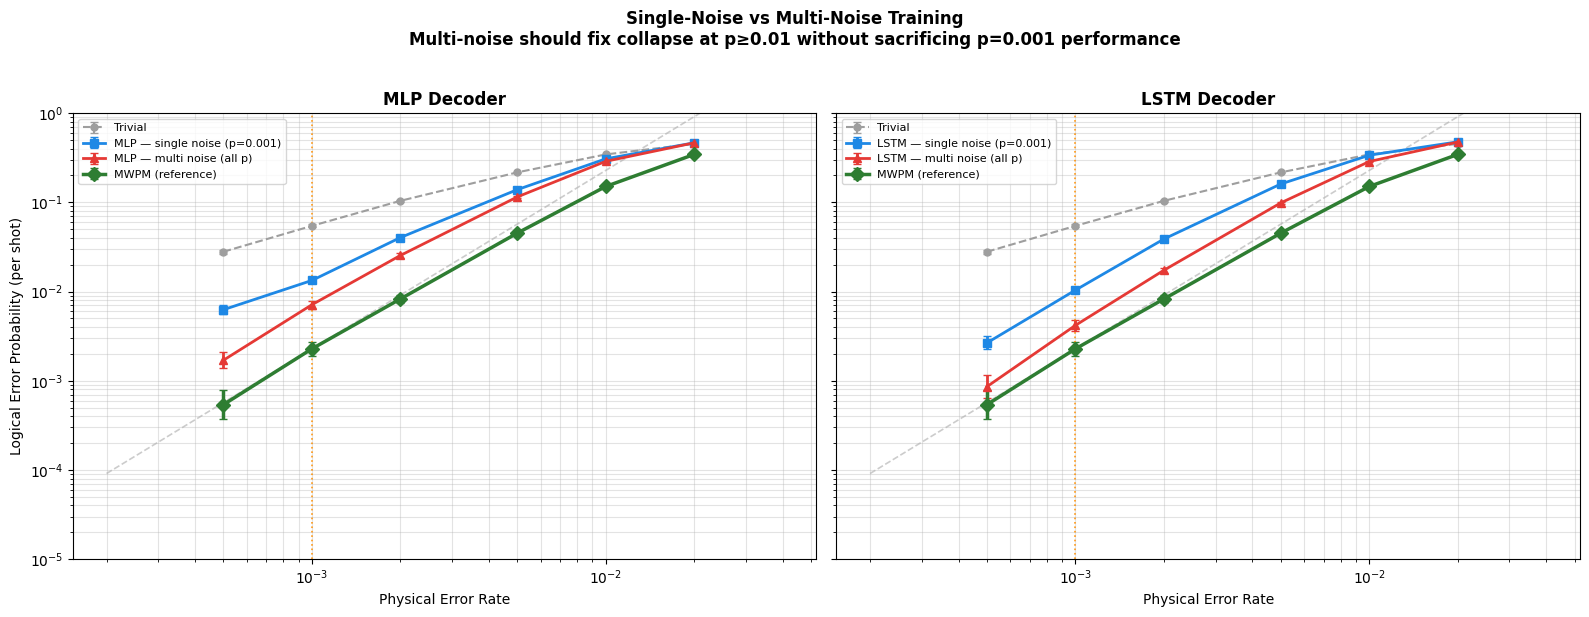

Saved → figures/03B_multi_noise_comparison.png


In [4]:
def wilson_ci(num_errors, num_shots, z=1.96):
    p = num_errors / num_shots
    denom = 1 + z**2/num_shots
    centre = (p + z**2/(2*num_shots)) / denom
    margin = z*np.sqrt(p*(1-p)/num_shots + z**2/(4*num_shots**2)) / denom
    lo = np.clip(centre-margin, 1e-10, 1.0)
    hi = np.clip(centre+margin, 1e-10, 1.0)
    return float(p-lo), float(hi-p)

def make_yerr(lers, shots=SWEEP_SHOTS):
    pairs = [wilson_ci(max(1, round(l*shots)), shots) for l in lers]
    lo, hi = zip(*pairs)
    return np.array([lo, hi])

ps = np.array(NOISE_LEVELS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, title, single_lers, multi_lers, label in [
    (ax1, 'MLP Decoder',  mlp_single_lers,  mlp_multi_lers,  'MLP'),
    (ax2, 'LSTM Decoder', lstm_single_lers, lstm_multi_lers, 'LSTM'),
]:
    # p² reference
    p_ref = np.array([2e-4, 4e-2])
    ax.plot(p_ref, mwpm_lers[1]*(p_ref/0.001)**2,
            ls='--', color='#CCCCCC', lw=1.2, zorder=0)

    ax.errorbar(ps, trivials, yerr=make_yerr(trivials),
                fmt='o--', color='#9E9E9E', lw=1.5, ms=5, capsize=3,
                label='Trivial')

    ax.errorbar(ps, single_lers, yerr=make_yerr(single_lers),
                fmt='s-', color='#1E88E5', lw=2, ms=6, capsize=3,
                label=f'{label} — single noise (p=0.001)')

    ax.errorbar(ps, multi_lers, yerr=make_yerr(multi_lers),
                fmt='^-', color='#E53935', lw=2, ms=6, capsize=3,
                label=f'{label} — multi noise (all p)')

    ax.errorbar(ps, mwpm_lers, yerr=make_yerr(mwpm_lers),
                fmt='D-', color='#2E7D32', lw=2.5, ms=7, capsize=3,
                label='MWPM (reference)')

    ax.axvline(x=0.001, color='#FF8F00', lw=1.2, ls=':', alpha=0.9)
    ax.loglog()
    ax.set_ylim(1e-5, 1)
    ax.grid(which='both', alpha=0.35)
    ax.set_xlabel('Physical Error Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')

ax1.set_ylabel('Logical Error Probability (per shot)')
plt.suptitle('Single-Noise vs Multi-Noise Training\n'
             'Multi-noise should fix collapse at p≥0.01 without sacrificing p=0.001 performance',
             fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig('figures/03B_multi_noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/03B_multi_noise_comparison.png")

---
## 4. Save Sweep Results for Notebook 13

In [5]:
np.save("results/mlp_multi_sweep.npy",
        np.array(list(zip(NOISE_LEVELS, mlp_multi_lers))))
np.save("results/lstm_multi_sweep.npy",
        np.array(list(zip(NOISE_LEVELS, lstm_multi_lers))))

print("=" * 60)
print("Multi-noise vs single-noise at p=0.001 (training noise):")
print("=" * 60)
idx_train = NOISE_LEVELS.index(0.001)
print(f"  MLP  single-noise : {100*mlp_single_lers[idx_train]:.4f}%")
print(f"  MLP  multi-noise  : {100*mlp_multi_lers[idx_train]:.4f}%")
print(f"  LSTM single-noise : {100*lstm_single_lers[idx_train]:.4f}%")
print(f"  LSTM multi-noise  : {100*lstm_multi_lers[idx_train]:.4f}%")
print()
print("At p=0.02 (out-of-distribution):")
idx_ood = NOISE_LEVELS.index(0.02)
print(f"  Trivial           : {100*trivials[idx_ood]:.4f}%")
print(f"  MLP  single-noise : {100*mlp_single_lers[idx_ood]:.4f}%"
      f"  ({'better' if mlp_single_lers[idx_ood]<trivials[idx_ood] else 'WORSE than trivial'})")
print(f"  MLP  multi-noise  : {100*mlp_multi_lers[idx_ood]:.4f}%"
      f"  ({'better' if mlp_multi_lers[idx_ood]<trivials[idx_ood] else 'WORSE than trivial'})")
print(f"  LSTM single-noise : {100*lstm_single_lers[idx_ood]:.4f}%"
      f"  ({'better' if lstm_single_lers[idx_ood]<trivials[idx_ood] else 'WORSE than trivial'})")
print(f"  LSTM multi-noise  : {100*lstm_multi_lers[idx_ood]:.4f}%"
      f"  ({'better' if lstm_multi_lers[idx_ood]<trivials[idx_ood] else 'WORSE than trivial'})")
print()
print("Saved → results/mlp_multi_sweep.npy")
print("Saved → results/lstm_multi_sweep.npy")

Multi-noise vs single-noise at p=0.001 (training noise):
  MLP  single-noise : 1.3320%
  MLP  multi-noise  : 0.7120%
  LSTM single-noise : 1.0380%
  LSTM multi-noise  : 0.4180%

At p=0.02 (out-of-distribution):
  Trivial           : 45.2880%
  MLP  single-noise : 46.5100%  (WORSE than trivial)
  MLP  multi-noise  : 46.4620%  (WORSE than trivial)
  LSTM single-noise : 47.6860%  (WORSE than trivial)
  LSTM multi-noise  : 47.4100%  (WORSE than trivial)

Saved → results/mlp_multi_sweep.npy
Saved → results/lstm_multi_sweep.npy
